# Task 1: Exploring and Visualizing the Iris Dataset

**Objective:** Load, inspect, and visualize the Iris dataset to understand data distributions and feature relationships.

**Dataset:** Iris Dataset (loaded via seaborn)

**Skills Covered:** pandas, descriptive statistics, matplotlib, seaborn


## Step 1: Import Required Libraries

In [1]:
# standard data handling and visualization libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# make plots look a bit cleaner
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

print("All libraries imported successfully.")


All libraries imported successfully.


## Step 2: Load the Dataset

In [2]:
# seaborn has the iris dataset built-in, so no need to download anything
iris_raw = sns.load_dataset("iris")

# make a working copy so we never accidentally mess with the original
df = iris_raw.copy()

print("Dataset loaded.")
print(f"Shape: {df.shape}  →  {df.shape[0]} rows, {df.shape[1]} columns")


Dataset loaded.
Shape: (150, 5)  →  150 rows, 5 columns


## Step 3: Basic Inspection

In [3]:
# first few rows to get a feel for the data
print("First 5 rows:")
df.head()


First 5 rows:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
# column names and data types — always good to check before doing anything
print("Column names:", df.columns.tolist())
print()
df.info()


Column names: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [5]:
# summary statistics — mean, std, min/max, quartiles
print("Summary statistics:")
df.describe()


Summary statistics:


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [6]:
# how many samples are there per species?
print("Value counts per species:")
print(df["species"].value_counts())
# perfectly balanced — 50 samples each, nice


Value counts per species:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


## Step 4: Data Visualization

### 4a. Scatter Plot — Feature Relationships

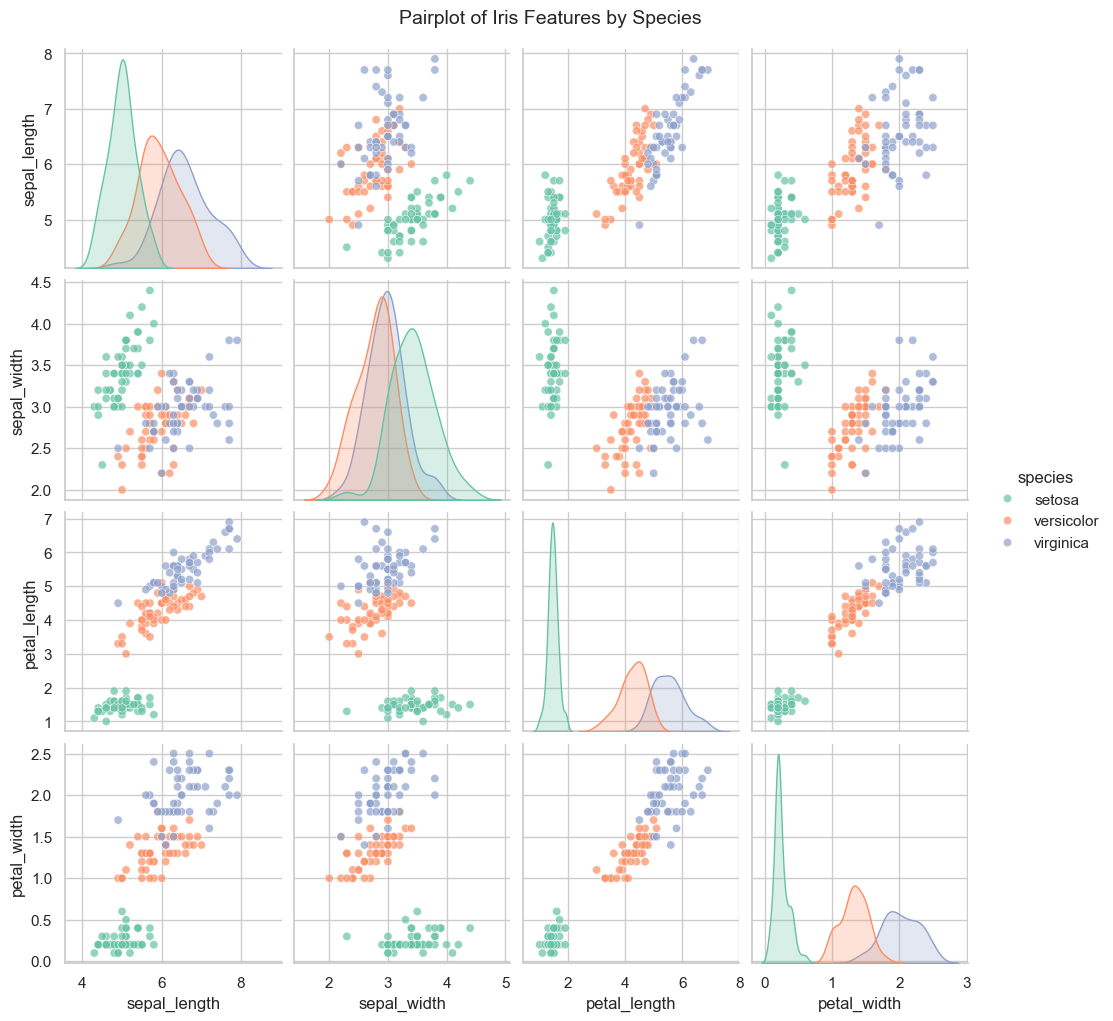

In [7]:
# a pairplot is a grid of scatter plots for every combination of numeric features
# the diagonal shows the distribution of each single feature
fig = sns.pairplot(df, hue="species", palette="Set2", plot_kws={"alpha": 0.7})
fig.fig.suptitle("Pairplot of Iris Features by Species", y=1.02, fontsize=14)
plt.show()
# you can already see that setosa is pretty well separated from the other two


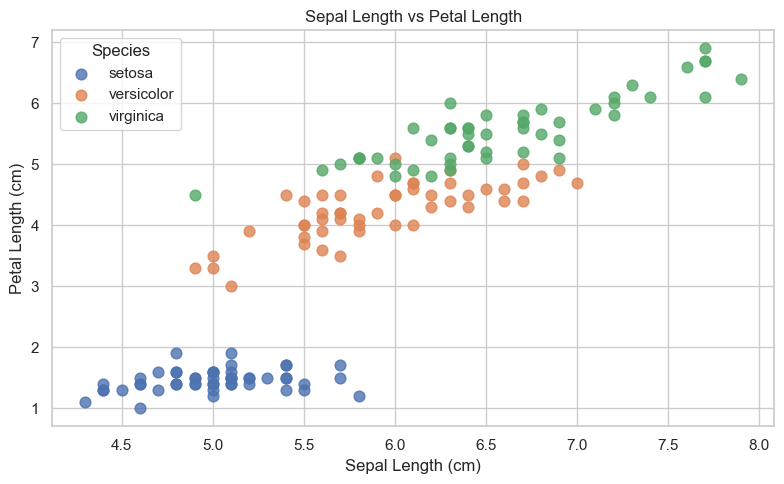

In [8]:
# let's also do a focused scatter plot: sepal length vs petal length
plt.figure(figsize=(8, 5))
for species, group in df.groupby("species"):
    plt.scatter(group["sepal_length"], group["petal_length"],
                label=species, alpha=0.8, s=60)

plt.xlabel("Sepal Length (cm)")
plt.ylabel("Petal Length (cm)")
plt.title("Sepal Length vs Petal Length")
plt.legend(title="Species")
plt.tight_layout()
plt.show()


### 4b. Histograms — Value Distributions

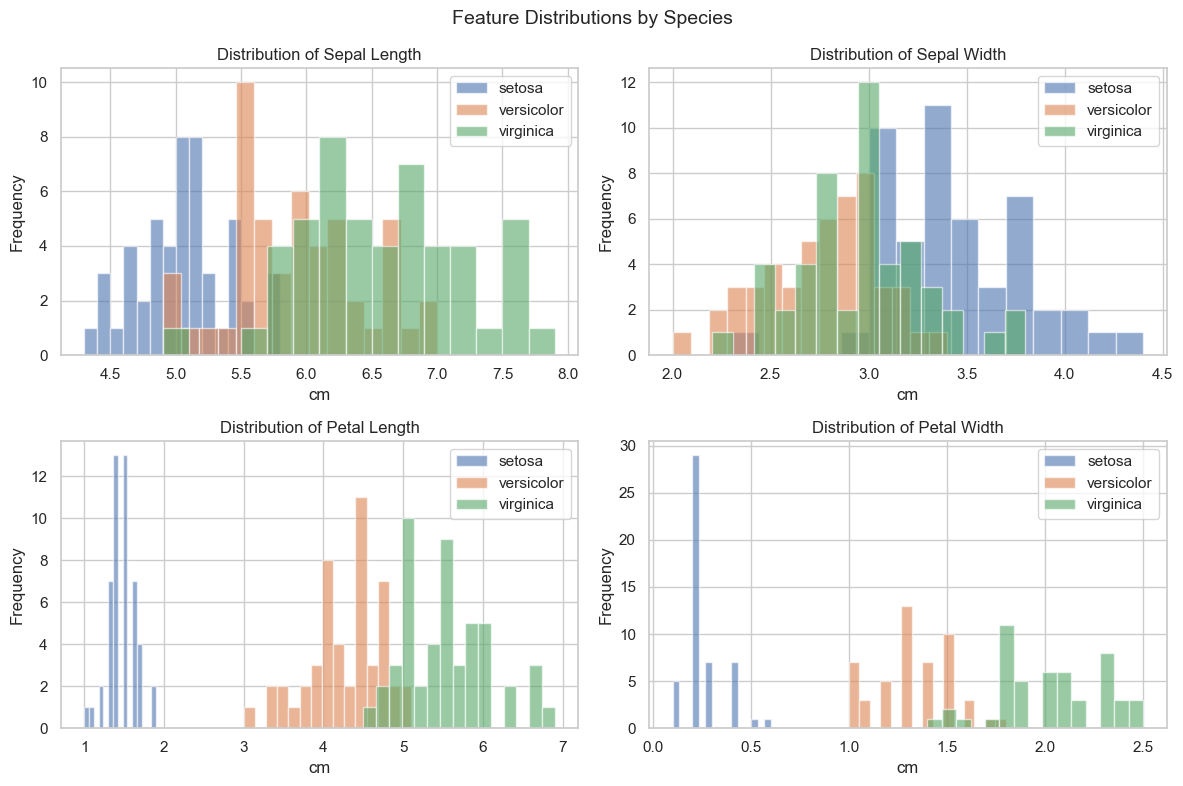

In [9]:
# plot a histogram for each numeric feature, grouped by species
features = ["sepal_length", "sepal_width", "petal_length", "petal_width"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feat in enumerate(features):
    for species, group in df.groupby("species"):
        axes[i].hist(group[feat], bins=15, alpha=0.6, label=species)
    axes[i].set_title(f"Distribution of {feat.replace('_', ' ').title()}")
    axes[i].set_xlabel("cm")
    axes[i].set_ylabel("Frequency")
    axes[i].legend()

plt.suptitle("Feature Distributions by Species", fontsize=14)
plt.tight_layout()
plt.show()
# petal length and petal width show the clearest separation between species


### 4c. Box Plots — Spotting Outliers

C:\Windows\Temp\ipykernel_3320\1515296318.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="species", y=feat, palette="Set2", ax=axes[i])
C:\Windows\Temp\ipykernel_3320\1515296318.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="species", y=feat, palette="Set2", ax=axes[i])
C:\Windows\Temp\ipykernel_3320\1515296318.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="species", y=feat, palette="Set2", ax=axes[i])
C:\Windows\Temp\ipykernel_3320\1515296318.py:6: FutureWarning: 

Passing `palette` without 

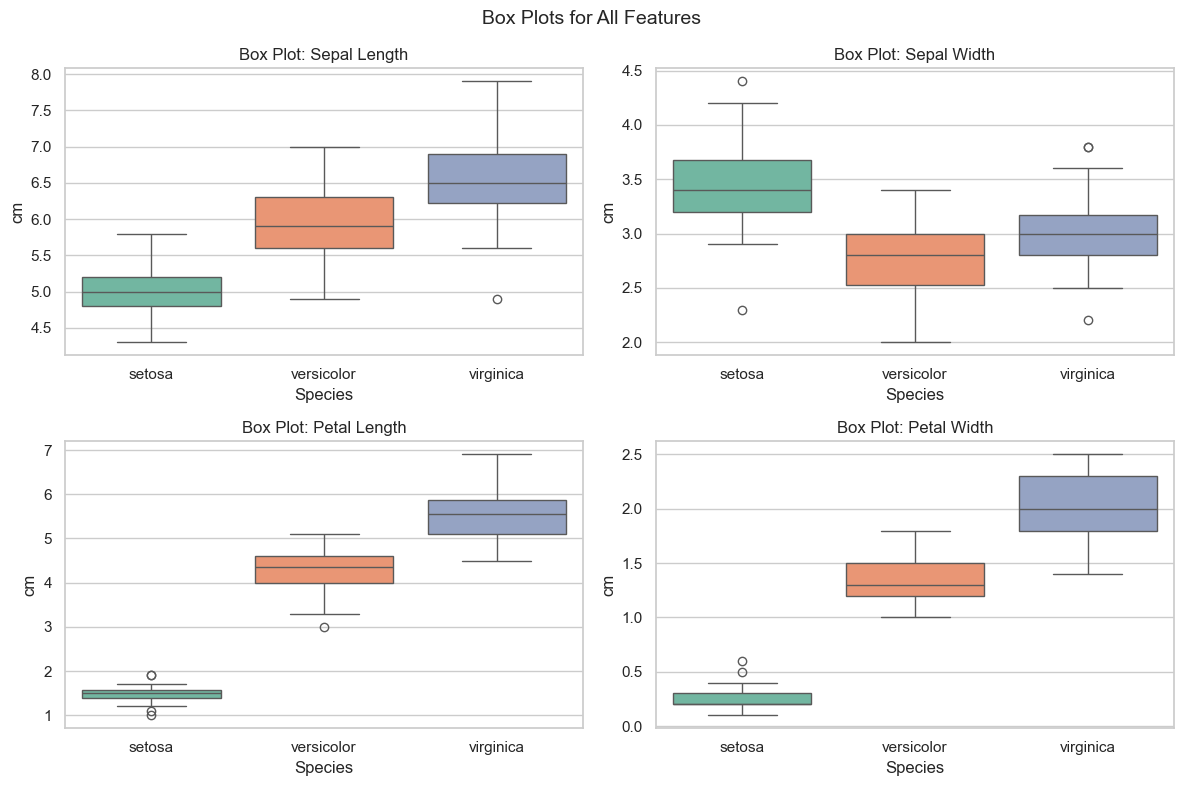

In [10]:
# box plots are great for comparing distributions and finding outliers
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feat in enumerate(features):
    sns.boxplot(data=df, x="species", y=feat, palette="Set2", ax=axes[i])
    axes[i].set_title(f"Box Plot: {feat.replace('_', ' ').title()}")
    axes[i].set_xlabel("Species")
    axes[i].set_ylabel("cm")

plt.suptitle("Box Plots for All Features", fontsize=14)
plt.tight_layout()
plt.show()
# a few outliers visible in sepal_width, but nothing too crazy


### 4d. Correlation Heatmap 


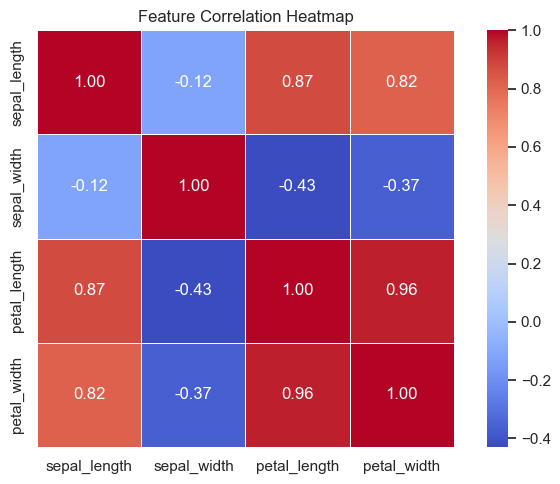

In [11]:
# heatmap of the correlation matrix — tells us which features move together
plt.figure(figsize=(7, 5))
corr = df.drop(columns="species").corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True, linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()
# petal length and petal width are highly correlated (0.96) — makes sense biologically


## Summary & Key Insights

- The dataset has **150 samples** across **3 species** (50 each) with 4 numeric features.
- **Petal length and petal width** are the most useful features for distinguishing species.
- **Setosa** is clearly separable from the other two species across all features.
- **Versicolor and Virginica** overlap somewhat, especially in sepal measurements.
- There are a small number of outliers in `sepal_width` but no missing values.
- Petal length and petal width have a very high correlation (~0.96).
